<a href="https://colab.research.google.com/github/NazHub1993/Deep-Learning/blob/main/GPU_Benchmarking.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [3]:
import tensorflow as tf
from tensorflow import keras
import matplotlib.pyplot as plt
import numpy as np

In [4]:
tf.config.experimental.list_physical_devices()

[PhysicalDevice(name='/physical_device:CPU:0', device_type='CPU')]

In [5]:
(x_train,y_train),(x_test,y_test)=tf.keras.datasets.cifar10.load_data()

170498071/170498071 ━━━━━━━━━━━━━━━━━━━━ 245s 1us/step


In [6]:
x_train.shape

(50000, 32, 32, 3)

In [7]:
y_train.shape

(50000, 1)

In [8]:
def plot_sample(index):
  plt.figure(figsize=(15,2))
  plt.imshow(x_train[index])

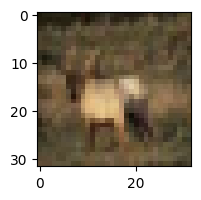

In [9]:
plot_sample(3)

In [10]:
x_train[0].shape

(32, 32, 3)

In [11]:
classes = ["airplane","automobile","bird","cat","deer","dog","frog","horse","ship","truck"]

In [12]:
y_train[3]

array([4], dtype=uint8)

In [13]:
classes[y_train[3][0]]

'deer'

#Preprocessing or scale images

In [14]:
x_train_scaled=x_train/255
x_test_scaled=x_test/255

#One hot encoding which makes the y_train and y_test into nodes

In [22]:
y_train_categorical=keras.utils.to_categorical(
    y_train,num_classes=10
)

y_test_categorical=keras.utils.to_categorical(
    y_test,num_classes=10
)

In [23]:
y_train[0:5]

array([[6],
       [9],
       [9],
       [4],
       [1]], dtype=uint8)

In [24]:
y_train_categorical[0:5]

array([[0., 0., 0., 0., 0., 0., 1., 0., 0., 0.],
       [0., 0., 0., 0., 0., 0., 0., 0., 0., 1.],
       [0., 0., 0., 0., 0., 0., 0., 0., 0., 1.],
       [0., 0., 0., 0., 1., 0., 0., 0., 0., 0.],
       [0., 1., 0., 0., 0., 0., 0., 0., 0., 0.]])

In [26]:
model=keras.Sequential(
   [ keras.layers.Flatten(input_shape=(32,32,3)),
    keras.layers.Dense(3000,activation='relu'),
    keras.layers.Dense(1000,activation='relu'),
    keras.layers.Dense(10,activation='sigmoid')
])

model.compile(
    optimizer='SGD',
    loss='categorical_crossentropy',
    metrics=['accuracy']
)

model.fit(x_train_scaled,y_train_categorical,epochs=50)

Epoch 1/50
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 136s 87ms/step - accuracy: 0.3555 - loss: 1.8121
Epoch 2/50
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 122s 78ms/step - accuracy: 0.4278 - loss: 1.6230
Epoch 3/50
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 126s 81ms/step - accuracy: 0.4562 - loss: 1.5418
Epoch 4/50
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 132s 85ms/step - accuracy: 0.4779 - loss: 1.4808
Epoch 5/50
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 148s 95ms/step - accuracy: 0.4964 - loss: 1.4335
Epoch 6/50
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 122s 78ms/step - accuracy: 0.5114 - loss: 1.3916
Epoch 7/50
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 120s 77ms/step - accuracy: 0.5270 - loss: 1.3517
Epoch 8/50
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 143s 77ms/step - accuracy: 0.5376 - loss: 1.3179
Epoch 9/50
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 119s 76ms/step - accuracy: 0.5473 - loss: 1.2860
Epoch 10/50
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 126s 81ms/step - accuracy: 0.5596 - loss: 1.2519
Epoch 11/50
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 124s 79ms/step - accuracy: 0.5702 - loss: 1.22

In [27]:
np.argmax(model.predict(x_test_scaled)[0])

313/313 ━━━━━━━━━━━━━━━━━━━━ 9s 30ms/step


np.int64(3)

In [28]:
def get_model():
  model = keras.Sequential([
            keras.layers.Flatten(input_shape=(32,32,3)),
            keras.layers.Dense(3000, activation='relu'),
            keras.layers.Dense(1000, activation='relu'),
            keras.layers.Dense(10, activation='sigmoid')
        ])

  model.compile(optimizer='SGD',
                  loss='categorical_crossentropy',
                  metrics=['accuracy'])
  return model

In [29]:
%%timeit -n1 -r1
with tf.device('/CPU:0'):
  cpu_model=get_model()
  cpu_model.fit(x_train_scaled,y_train_categorical,epochs=5)

/usr/local/lib/python3.12/dist-packages/keras/src/layers/reshaping/flatten.py:37: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


TypeError: TensorFlowTrainer.fit() got an unexpected keyword argument 'epoch'

In [ ]:
%%timeit -n1 -r1
with tf.device('/GPU:0'):
  gpu_model=get_model()
  gpu_model.fit(x_train_scaled,y_train_categorical,epochs=5)
